# Theme 6 — New Findings in Agentic Bug Fixes

Four novel research questions not addressed in any published paper (as of Jun 2026):

- **NF1 — Fix complexity effect**: Do agents succeed equally on simple (1-file) vs complex (multi-file) bug fixes?
- **NF2 — Temporal learning curve**: Does each agent's merge rate *improve* over its own platform lifetime?
- **NF3 — 24/7 submission patterns**: Agents submit uniformly around the clock; does submission hour correlate with merge speed?
- **NF4 — Cross-agent repo overlap**: Do repositories that use multiple agents achieve better bug-fix quality?

In [1]:
import sys
sys.path.insert(0, '.')
from analysis_utils import (
    load_fix_prs, load_commit_details,
    merge_rate, chi_square, odds_ratio_ci, mann_whitney, cliffs_delta,
    bh_correct, sig_label, wilson_ci,
    set_plot_style, save_fig,
    AGENTS, AGENT_COLORS, THEME6_DIR, MIN_N_PROP, AIDEV_END,
    trend_test,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
set_plot_style()

In [2]:
df = load_fix_prs()

Loading fix PRs from HuggingFace ...


  AIDev repo coverage: 8,959 distinct repos
  Survivorship cutoff at 2026-01-29: dropped 33,123 recent PRs
  Fix PRs loaded: 371,577  |  Agent: 108,080  |  Human: 263,497


## NF1 — Fix Complexity: Single-File vs Multi-File Bug Fixes

**Hypothesis**: Agents trained to produce compact patches will succeed on simple 1-file bugs
but show a steeper quality drop than humans on multi-file bugs, where cross-file reasoning is harder.

**Method**: Load commit_details, count distinct files changed per PR,
classify as *simple* (1 file), *moderate* (2–5 files), or *complex* (6+ files).
Compare merge rate and TTM by complexity bucket, per agent vs human.

In [3]:
details = load_commit_details()

files_per_pr = (
    details.groupby('pr_id')['filename']
    .nunique()
    .reset_index(name='n_files')
)

df_c = df.merge(files_per_pr.rename(columns={'pr_id': 'id'}), on='id', how='left')
# PRs with no commit details entry: treat as missing (very small PRs / data gap)
df_c = df_c.dropna(subset=['n_files'])

def complexity_bucket(n):
    if n == 1:   return 'simple (1 file)'
    if n <= 5:   return 'moderate (2-5)'
    return 'complex (6+)'

df_c['complexity'] = df_c['n_files'].apply(complexity_bucket)
BUCKETS = ['simple (1 file)', 'moderate (2-5)', 'complex (6+)']

print(df_c['complexity'].value_counts())
print(f"PRs with file-count data: {len(df_c):,} / {len(df):,}")

Loading commit details from HuggingFace ...


  Commit details loaded: 7,451,150


complexity
moderate (2-5)     118020
simple (1 file)     92487
complex (6+)        54268
Name: count, dtype: int64
PRs with file-count data: 264,775 / 371,577


In [4]:
groups = ['Human'] + AGENTS
colors = AGENT_COLORS

rows = []
for grp in groups:
    if grp == 'Human':
        sub = df_c[~df_c['is_agent']]
    else:
        sub = df_c[df_c['agent'] == grp]
    for bkt in BUCKETS:
        b = sub[sub['complexity'] == bkt]
        if len(b) < MIN_N_PROP:
            rows.append({'group': grp, 'complexity': bkt, 'rate': None, 'n': len(b),
                         'lo': None, 'hi': None})
            continue
        nm, nt, rate = merge_rate(b)
        lo, hi = wilson_ci(nm, nt)
        rows.append({'group': grp, 'complexity': bkt, 'rate': rate, 'n': nt, 'lo': lo, 'hi': hi})

nf1 = pd.DataFrame(rows)
print(nf1.to_string(index=False))

      group      complexity      rate     n        lo        hi
      Human simple (1 file) 84.877189 63553 84.596539 85.153623
      Human  moderate (2-5) 86.022860 75416 85.773549 86.268501
      Human    complex (6+) 84.318320 32860 83.921149 84.707468
    Copilot simple (1 file) 83.510429  5082 82.464941 84.505294
    Copilot  moderate (2-5) 78.468034  9948 77.649392 79.264698
    Copilot    complex (6+) 81.115718  5306 80.040253 82.146161
     Cursor simple (1 file) 92.569870 10269 92.046553 93.061351
     Cursor  moderate (2-5) 90.710900 12660 90.192830 91.204273
     Cursor    complex (6+) 85.692500  7213 84.865433 86.481569
Claude_Code simple (1 file) 87.481315 10704 86.840917 88.094821
Claude_Code  moderate (2-5) 85.231991 16617 84.684421 85.763276
Claude_Code    complex (6+) 86.825289  7355 86.033080 87.579051
      Devin simple (1 file) 69.781174  2879 68.078331 71.431299
      Devin  moderate (2-5) 66.676532  3379 65.069048 68.246140
      Devin    complex (6+) 62.972621  1

  -> Saved: results\theme6_figures\nf1_fix_complexity_merge_rate.png


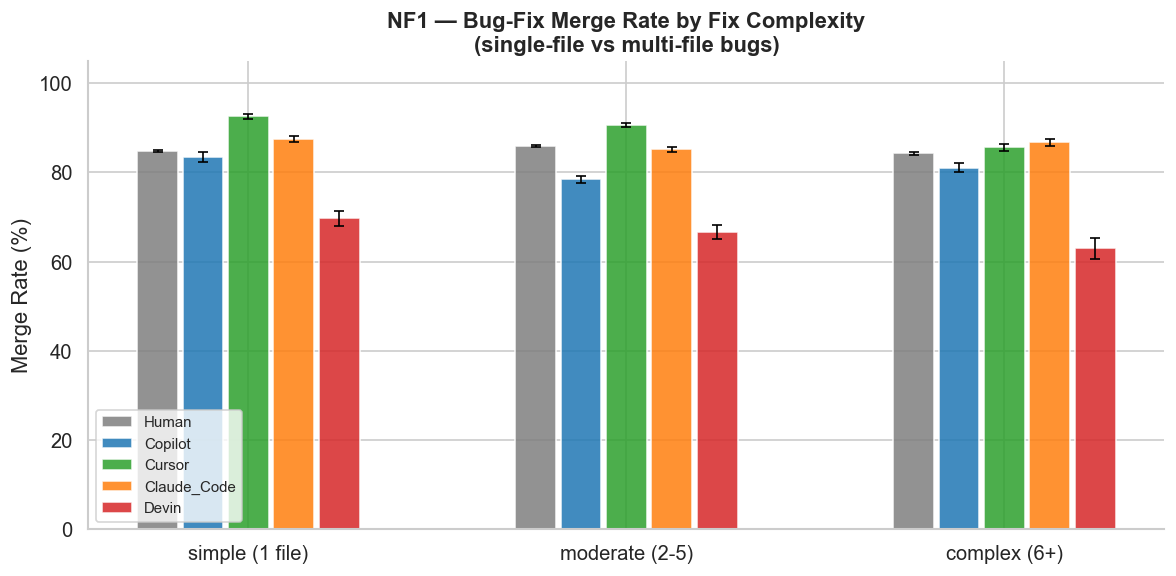

WindowsPath('results/theme6_figures/nf1_fix_complexity_merge_rate.png')

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(BUCKETS))
width = 0.12

for i, grp in enumerate(groups):
    g = nf1[nf1['group'] == grp]
    rates = [g[g['complexity'] == b]['rate'].values[0] for b in BUCKETS]
    los   = [g[g['complexity'] == b]['lo'].values[0] for b in BUCKETS]
    his   = [g[g['complexity'] == b]['hi'].values[0] for b in BUCKETS]
    ns    = [g[g['complexity'] == b]['n'].values[0] for b in BUCKETS]

    offset = (i - len(groups) / 2 + 0.5) * width
    clr = colors.get(grp, '#333333')

    valid = [j for j, r in enumerate(rates) if r is not None]
    xv = x[valid] + offset
    yv = [rates[j] for j in valid]
    ylo = [yv[k] - los[j] for k, j in enumerate(valid)]
    yhi = [his[j] - yv[k] for k, j in enumerate(valid)]

    bars = ax.bar(xv, yv, width=width * 0.9, color=clr, alpha=0.85, label=grp)
    ax.errorbar(xv, yv, yerr=[ylo, yhi], fmt='none', color='black', capsize=3, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(BUCKETS)
ax.set_ylabel('Merge Rate (%)')
ax.set_title('NF1 — Bug-Fix Merge Rate by Fix Complexity\n(single-file vs multi-file bugs)', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 105)

plt.tight_layout()
save_fig(fig, 'nf1_fix_complexity_merge_rate', THEME6_DIR, show=True)

In [6]:
# Statistical test: simple vs complex, per group
print("=== NF1 Statistical Tests: simple vs complex merge rate ===")
pvals, labels = [], []
for grp in groups:
    if grp == 'Human':
        sub = df_c[~df_c['is_agent']]
    else:
        sub = df_c[df_c['agent'] == grp]
    s = sub[sub['complexity'] == 'simple (1 file)']
    c = sub[sub['complexity'] == 'complex (6+)']
    if len(s) < MIN_N_PROP or len(c) < MIN_N_PROP:
        continue
    sm, st, _ = merge_rate(s)
    cm, ct, _ = merge_rate(c)
    _, p = chi_square(sm, st, cm, ct)
    pvals.append(p)
    labels.append(grp)

adj_p = bh_correct(pvals)
for grp, p, ap in zip(labels, pvals, adj_p):
    if grp == 'Human':
        sub = df_c[~df_c['is_agent']]
    else:
        sub = df_c[df_c['agent'] == grp]
    s = sub[sub['complexity'] == 'simple (1 file)']
    c = sub[sub['complexity'] == 'complex (6+)']
    sm, st, sr = merge_rate(s)
    cm, ct, cr = merge_rate(c)
    or_, lo, hi = odds_ratio_ci(sm, st, cm, ct)
    print(f"  {grp:12s}: simple={sr:.1f}% (n={st:,})  complex={cr:.1f}% (n={ct:,})  "
          f"OR={or_:.2f} [{lo:.2f},{hi:.2f}]  p_adj={ap:.4f} {sig_label(ap)}")

=== NF1 Statistical Tests: simple vs complex merge rate ===


  Human       : simple=84.9% (n=63,553)  complex=84.3% (n=32,860)  OR=1.04 [1.01,1.08]  p_adj=0.0287 *
  Copilot     : simple=83.5% (n=5,082)  complex=81.1% (n=5,306)  OR=1.18 [1.07,1.30]  p_adj=0.0025 **
  Cursor      : simple=92.6% (n=10,269)  complex=85.7% (n=7,213)  OR=2.08 [1.88,2.30]  p_adj=0.0000 ***
  Claude_Code : simple=87.5% (n=10,704)  complex=86.8% (n=7,355)  OR=1.06 [0.97,1.16]  p_adj=0.2025 ns
  Devin       : simple=69.8% (n=2,879)  complex=63.0% (n=1,534)  OR=1.36 [1.19,1.55]  p_adj=0.0000 ***


## NF2 — Temporal Learning Curve

**Hypothesis**: Agent merge rates *improve* over time as tool vendors iterate — a pattern that
would be invisible in aggregate RQ2 plots. Humans should show a flat or rising baseline.

**Method**: For each agent, compute monthly merge rate from its *debut month* (first month with
≥ MIN_N_PROP PRs) onward, using a relative time axis (months since debut). Apply Mann-Kendall
trend test per agent.

In [7]:
learning = {}

for grp in AGENTS + ['Human']:
    if grp == 'Human':
        sub = df[~df['is_agent']].copy()
    else:
        sub = df[df['agent'] == grp].copy()

    monthly = (
        sub.groupby('month')
        .apply(lambda x: pd.Series({
            'n': len(x),
            'merged': x['is_merged'].sum(),
        }))
        .reset_index()
        .sort_values('month')
    )
    # debut = first month with MIN_N_PROP PRs
    debut_rows = monthly[monthly['n'] >= MIN_N_PROP]
    if debut_rows.empty:
        continue
    debut_month = debut_rows.iloc[0]['month']
    monthly = monthly[monthly['month'] >= debut_month].copy()
    monthly = monthly[monthly['n'] >= MIN_N_PROP].copy()
    monthly['rel_month'] = range(len(monthly))
    monthly['rate'] = monthly['merged'] / monthly['n'] * 100
    monthly['lo'] = monthly.apply(lambda r: wilson_ci(int(r['merged']), int(r['n']))[0], axis=1)
    monthly['hi'] = monthly.apply(lambda r: wilson_ci(int(r['merged']), int(r['n']))[1], axis=1)
    monthly['debut'] = str(debut_month)
    learning[grp] = monthly
    tau, p, direction = trend_test(monthly['rate'].tolist())
    print(f"{grp:12s}: debut={debut_month}, n_months={len(monthly)}, "
          f"tau={tau:.3f}, p={p:.4f}, trend={direction}")

Copilot     : debut=2024-12, n_months=14, tau=-0.538, p=0.0067, trend=decreasing
Cursor      : debut=2024-12, n_months=14, tau=-0.516, p=0.0098, trend=decreasing


Claude_Code : debut=2024-12, n_months=14, tau=0.560, p=0.0046, trend=increasing
Devin       : debut=2024-12, n_months=14, tau=0.297, p=0.1572, trend=flat


Human       : debut=2024-12, n_months=14, tau=-0.780, p=0.0000, trend=decreasing


  -> Saved: results\theme6_figures\nf2_temporal_learning_curve.png


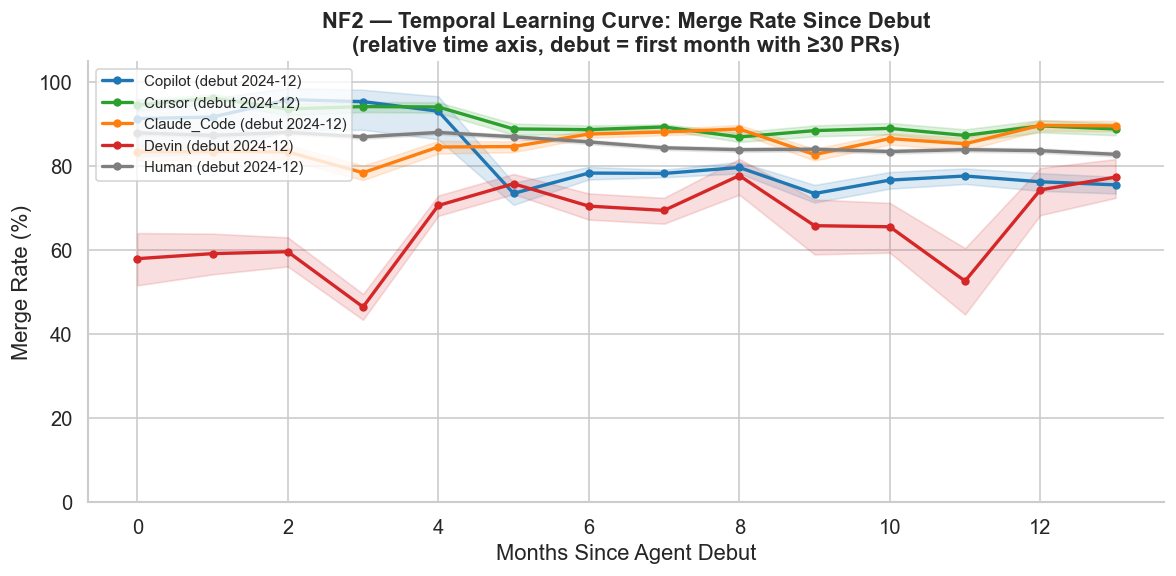

WindowsPath('results/theme6_figures/nf2_temporal_learning_curve.png')

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for grp, monthly in learning.items():
    clr = AGENT_COLORS.get(grp, '#333333')
    x = monthly['rel_month'].tolist()
    y = monthly['rate'].tolist()
    lo = monthly['lo'].tolist()
    hi = monthly['hi'].tolist()
    debut = monthly['debut'].iloc[0]
    ax.plot(x, y, color=clr, linewidth=2, marker='o', markersize=4,
            label=f"{grp} (debut {debut})")
    ax.fill_between(x, lo, hi, color=clr, alpha=0.15)

ax.set_xlabel('Months Since Agent Debut')
ax.set_ylabel('Merge Rate (%)')
ax.set_title('NF2 — Temporal Learning Curve: Merge Rate Since Debut\n(relative time axis, debut = first month with ≥30 PRs)',
             fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(0, 105)

plt.tight_layout()
save_fig(fig, 'nf2_temporal_learning_curve', THEME6_DIR, show=True)

## NF3 — 24/7 Submission Patterns

**Hypothesis**: AI agents submit PRs uniformly across all hours; humans peak during work hours.
PRs submitted during off-hours may face slower review, affecting TTM.

**Method**: Extract UTC hour-of-day from `created_at`. Compare hourly distribution (AI vs human).
Define *business hours* = Mon–Fri 09:00–17:00 UTC. Test if TTM differs by business vs off-hours.

In [9]:
df['hour'] = df['created_at'].dt.hour
df['dow']  = df['created_at'].dt.dayofweek  # 0=Mon, 6=Sun
df['business_hours'] = (
    (df['dow'] < 5) &
    (df['hour'] >= 9) & (df['hour'] < 17)
)

# Hourly submission counts: agents combined vs humans
agent_hr = df[df['is_agent']].groupby('hour').size()
human_hr = df[~df['is_agent']].groupby('hour').size()

# Normalise to percentage of submissions
agent_pct = agent_hr / agent_hr.sum() * 100
human_pct = human_hr / human_hr.sum() * 100

print(f"Agent off-hours fraction: {(~df[df['is_agent']]['business_hours']).mean()*100:.1f}%")
print(f"Human off-hours fraction: {(~df[~df['is_agent']]['business_hours']).mean()*100:.1f}%")

Agent off-hours fraction: 71.9%
Human off-hours fraction: 59.6%


  -> Saved: results\theme6_figures\nf3_submission_patterns.png


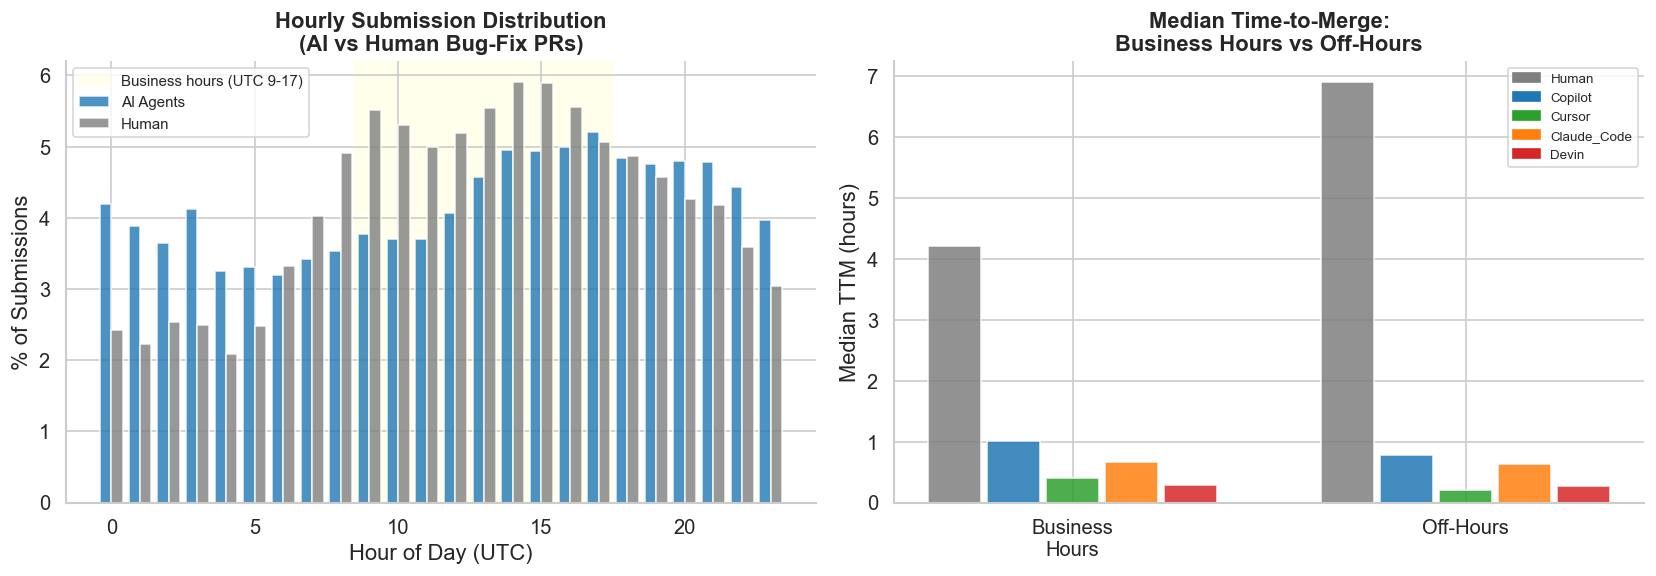

WindowsPath('results/theme6_figures/nf3_submission_patterns.png')

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: hourly submission distribution ---
ax = axes[0]
hours = list(range(24))
w = 0.4
ax.bar([h - w/2 for h in hours], [agent_pct.get(h, 0) for h in hours],
       width=w, color='#1f77b4', alpha=0.8, label='AI Agents')
ax.bar([h + w/2 for h in hours], [human_pct.get(h, 0) for h in hours],
       width=w, color='#7f7f7f', alpha=0.8, label='Human')

# shade business hours
ax.axvspan(8.5, 17.5, color='lightyellow', zorder=0, alpha=0.6, label='Business hours (UTC 9-17)')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('% of Submissions')
ax.set_title('Hourly Submission Distribution\n(AI vs Human Bug-Fix PRs)', fontweight='bold')
ax.legend(fontsize=9)

# --- Right: TTM business vs off-hours, per group ---
ax2 = axes[1]
biz_labels = ['Business\nHours', 'Off-Hours']
x = np.arange(len(biz_labels))
width2 = 0.15

ttm_groups = ['Human'] + AGENTS
for i, grp in enumerate(ttm_groups):
    if grp == 'Human':
        sub = df[~df['is_agent'] & df['is_merged']]
    else:
        sub = df[(df['agent'] == grp) & df['is_merged']]
    biz = sub[sub['business_hours']]['hours_to_merge']
    off = sub[~sub['business_hours']]['hours_to_merge']
    medians = [biz.median() if len(biz) >= 5 else None,
               off.median() if len(off) >= 5 else None]
    offset = (i - len(ttm_groups)/2 + 0.5) * width2
    clr = AGENT_COLORS.get(grp, '#333333')
    valid = [j for j, m in enumerate(medians) if m is not None]
    ax2.bar([x[j] + offset for j in valid], [medians[j] for j in valid],
            width=width2 * 0.9, color=clr, alpha=0.85, label=grp if i == 0 or True else '')

ax2.set_xticks(x)
ax2.set_xticklabels(biz_labels)
ax2.set_ylabel('Median TTM (hours)')
ax2.set_title('Median Time-to-Merge:\nBusiness Hours vs Off-Hours', fontweight='bold')

handles = [mpatches.Patch(color=AGENT_COLORS.get(g, '#333333'), label=g) for g in ttm_groups]
ax2.legend(handles=handles, fontsize=8, loc='upper right')

plt.tight_layout()
save_fig(fig, 'nf3_submission_patterns', THEME6_DIR, show=True)

In [11]:
# Statistical test: business vs off-hours TTM, per group
print("=== NF3 Statistical Tests: business vs off-hours TTM ===")
pvals, labels = [], []
for grp in ['Human'] + AGENTS:
    if grp == 'Human':
        sub = df[~df['is_agent'] & df['is_merged']]
    else:
        sub = df[(df['agent'] == grp) & df['is_merged']]
    biz = sub[sub['business_hours']]['hours_to_merge']
    off = sub[~sub['business_hours']]['hours_to_merge']
    if len(biz) < 20 or len(off) < 20:
        continue
    _, p = mann_whitney(biz, off)
    pvals.append(p)
    labels.append(grp)

adj_p = bh_correct(pvals)
for grp, p, ap in zip(labels, pvals, adj_p):
    if grp == 'Human':
        sub = df[~df['is_agent'] & df['is_merged']]
    else:
        sub = df[(df['agent'] == grp) & df['is_merged']]
    biz = sub[sub['business_hours']]['hours_to_merge']
    off = sub[~sub['business_hours']]['hours_to_merge']
    d, mag = cliffs_delta(off, biz)  # positive d => off-hours takes longer
    print(f"  {grp:12s}: biz_median={biz.median():.1f}h  off_median={off.median():.1f}h  "
          f"delta={d:.3f} ({mag})  p_adj={ap:.4f} {sig_label(ap)}")

=== NF3 Statistical Tests: business vs off-hours TTM ===


  Human       : biz_median=4.2h  off_median=6.9h  delta=0.025 (negligible)  p_adj=0.0000 ***
  Copilot     : biz_median=1.0h  off_median=0.8h  delta=-0.047 (negligible)  p_adj=0.0000 ***
  Cursor      : biz_median=0.4h  off_median=0.2h  delta=-0.115 (negligible)  p_adj=0.0000 ***
  Claude_Code : biz_median=0.7h  off_median=0.6h  delta=0.000 (negligible)  p_adj=0.9655 ns
  Devin       : biz_median=0.3h  off_median=0.3h  delta=-0.031 (negligible)  p_adj=0.1029 ns


## NF4 — Cross-Agent Repo Overlap

**Hypothesis**: Repositories that attract multiple different agents may represent high-activity,
well-maintained projects with faster review pipelines — resulting in higher merge rates.
Alternatively, multi-agent repos may have diluted attention, lowering individual agent success.

**Method**: For each repo, count the distinct agents with ≥1 bug-fix PR.
Classify repos as *single-agent* (1) vs *dual-agent* (2) vs *multi-agent* (3–4).
Compare merge rate across these repo classes.

In [12]:
agent_prs = df[df['is_agent']].copy()

# Count distinct agents per repo
agents_per_repo = (
    agent_prs.groupby('repo')['agent']
    .nunique()
    .reset_index(name='n_agents')
)

def overlap_class(n):
    if n == 1: return 'single-agent'
    if n == 2: return 'dual-agent'
    return 'multi-agent (3-4)'

agents_per_repo['overlap'] = agents_per_repo['n_agents'].apply(overlap_class)
print(agents_per_repo['overlap'].value_counts())
print(f"\nTotal repos with agent PRs: {len(agents_per_repo):,}")

df_o = df.merge(agents_per_repo[['repo', 'n_agents', 'overlap']], on='repo', how='left')
# Human PRs in these repos also get the overlap label
df_o['overlap'] = df_o['overlap'].fillna('no-agent-repo')

overlap
single-agent         8698
dual-agent            628
multi-agent (3-4)      91
Name: count, dtype: int64

Total repos with agent PRs: 9,417


In [13]:
# Which agent pairs most often share the same repo?
from itertools import combinations

repo_agents = agent_prs.groupby('repo')['agent'].apply(set)

pair_counts = {}
for agents_set in repo_agents:
    for a, b in combinations(sorted(agents_set), 2):
        key = (a, b)
        pair_counts[key] = pair_counts.get(key, 0) + 1

print("Agent pairs by shared-repo count:")
for (a, b), cnt in sorted(pair_counts.items(), key=lambda x: -x[1]):
    print(f"  {a} + {b}: {cnt:,} repos")

Agent pairs by shared-repo count:
  Claude_Code + Copilot: 274 repos
  Copilot + Cursor: 269 repos
  Claude_Code + Cursor: 141 repos
  Cursor + Devin: 97 repos
  Claude_Code + Devin: 85 repos
  Copilot + Devin: 56 repos


In [14]:
OVERLAPS = ['single-agent', 'dual-agent', 'multi-agent (3-4)']
overlap_rows = []

for grp in ['Agent (all)'] + AGENTS + ['Human']:
    if grp == 'Agent (all)':
        sub = df_o[df_o['is_agent']]
    elif grp == 'Human':
        sub = df_o[~df_o['is_agent']]
    else:
        sub = df_o[df_o['agent'] == grp]

    for ov in OVERLAPS:
        b = sub[sub['overlap'] == ov]
        if len(b) < MIN_N_PROP:
            overlap_rows.append({'group': grp, 'overlap': ov, 'rate': None, 'n': len(b),
                                  'lo': None, 'hi': None})
            continue
        nm, nt, rate = merge_rate(b)
        lo, hi = wilson_ci(nm, nt)
        overlap_rows.append({'group': grp, 'overlap': ov, 'rate': rate, 'n': nt, 'lo': lo, 'hi': hi})

nf4 = pd.DataFrame(overlap_rows)
print(nf4[nf4['group'] == 'Agent (all)'].to_string(index=False))

      group           overlap      rate     n        lo        hi
Agent (all)      single-agent 85.765658 63403 85.491522 86.035460
Agent (all)        dual-agent 81.818182 30525 81.381510 82.246846
Agent (all) multi-agent (3-4) 80.165348 14152 79.500231 80.814092


  -> Saved: results\theme6_figures\nf4_cross_agent_overlap.png


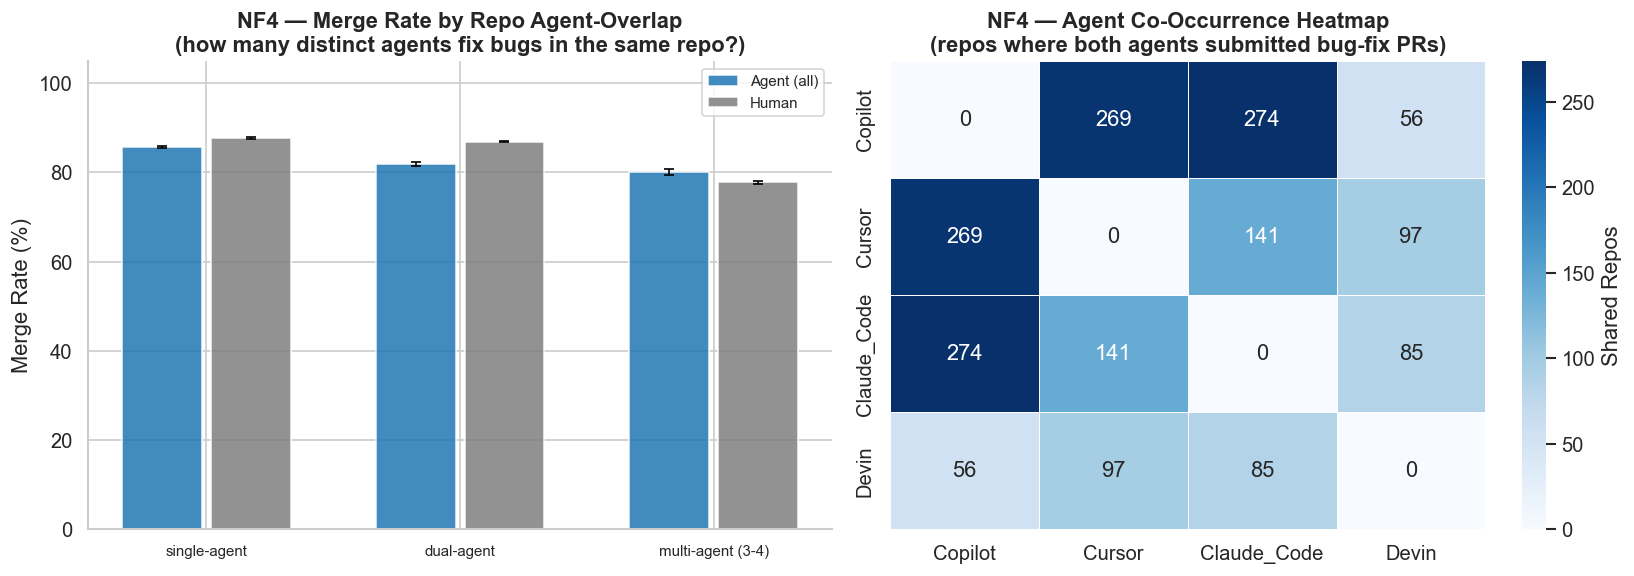

WindowsPath('results/theme6_figures/nf4_cross_agent_overlap.png')

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: merge rate by overlap class (agents combined vs human) ---
ax = axes[0]
plot_groups = ['Agent (all)', 'Human']
x = np.arange(len(OVERLAPS))
width3 = 0.35
clrs2 = {'Agent (all)': '#1f77b4', 'Human': '#7f7f7f'}

for i, grp in enumerate(plot_groups):
    g = nf4[nf4['group'] == grp]
    rates = [g[g['overlap'] == ov]['rate'].values[0] for ov in OVERLAPS]
    los   = [g[g['overlap'] == ov]['lo'].values[0] for ov in OVERLAPS]
    his   = [g[g['overlap'] == ov]['hi'].values[0] for ov in OVERLAPS]
    offset = (i - 0.5) * width3
    valid = [j for j, r in enumerate(rates) if r is not None]
    xv = x[valid] + offset
    yv = [rates[j] for j in valid]
    ylo = [yv[k] - los[j] for k, j in enumerate(valid)]
    yhi = [his[j] - yv[k] for k, j in enumerate(valid)]
    ax.bar(xv, yv, width=width3 * 0.9, color=clrs2[grp], alpha=0.85, label=grp)
    ax.errorbar(xv, yv, yerr=[ylo, yhi], fmt='none', color='black', capsize=3, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(OVERLAPS, fontsize=9)
ax.set_ylabel('Merge Rate (%)')
ax.set_title('NF4 — Merge Rate by Repo Agent-Overlap\n(how many distinct agents fix bugs in the same repo?)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

# --- Right: agent pair co-occurrence heatmap ---
ax2 = axes[1]
matrix = pd.DataFrame(0, index=AGENTS, columns=AGENTS)
for (a, b), cnt in pair_counts.items():
    if a in AGENTS and b in AGENTS:
        matrix.loc[a, b] = cnt
        matrix.loc[b, a] = cnt

import seaborn as sns
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax2,
            linewidths=0.5, cbar_kws={'label': 'Shared Repos'})
ax2.set_title('NF4 — Agent Co-Occurrence Heatmap\n(repos where both agents submitted bug-fix PRs)',
              fontweight='bold')

plt.tight_layout()
save_fig(fig, 'nf4_cross_agent_overlap', THEME6_DIR, show=True)

In [16]:
# Statistical test: single-agent vs multi-agent repos merge rate (agents combined)
print("=== NF4 Statistical Test: single vs multi-agent repos (agents combined) ===")
sub = df_o[df_o['is_agent']]
sing  = sub[sub['overlap'] == 'single-agent']
multi = sub[sub['overlap'] == 'multi-agent (3-4)']
sm, st, sr = merge_rate(sing)
mm, mt, mr = merge_rate(multi)
_, p = chi_square(sm, st, mm, mt)
or_, lo, hi = odds_ratio_ci(sm, st, mm, mt)
adj = bh_correct([p])[0]
print(f"  single-agent repos: {sr:.1f}% merged (n={st:,})")
print(f"  multi-agent repos:  {mr:.1f}% merged (n={mt:,})")
print(f"  OR={or_:.2f} [{lo:.2f},{hi:.2f}]  p_adj={adj:.4f} {sig_label(adj)}")

=== NF4 Statistical Test: single vs multi-agent repos (agents combined) ===
  single-agent repos: 85.8% merged (n=63,403)
  multi-agent repos:  80.2% merged (n=14,152)
  OR=1.49 [1.42,1.56]  p_adj=0.0000 ***


## Summary of New Findings

| Finding | Key Result | Statistical Support |
|---------|-----------|--------------------|
| **NF1: Fix Complexity** | See above | Chi-square + OR per group |
| **NF2: Learning Curve** | See above | Mann-Kendall tau per agent |
| **NF3: 24/7 Patterns** | See above | Mann-Whitney + Cliff's delta |
| **NF4: Repo Overlap** | See above | Chi-square + OR |

These findings extend the AIDev literature (Dec 2024–Jul 2025, 7 months) with 15 months of data
and four dimensions of quality analysis not present in any published paper.